In [1]:
import os
import sys
import joblib

sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler
from torch.utils.data import DataLoader, TensorDataset

from utils.models import build_model
from utils.preprocessing import (
    FEATURES,
    PROPERTY_BOOLEAN_FEATURES,
    filter_labels
)
from utils.evaluation import evaluate_model
from property_factory import build_properties
import property_driven_ml.logics as pml_logics
from datetime import date

In [2]:
# =========================
# Define datasets
# =========================
# df_cicids_combined_train = pd.read_csv("../data/cicids_combined_balanced_train.tsv", on_bad_lines="skip", delimiter="\t")
# df_cicids_combined_test = pd.read_csv("../data/cicids_combined_test.tsv", on_bad_lines="skip", delimiter="\t")
# df_ciciot2023_train = pd.read_csv("../data/ciciot2023_balanced_train.tsv", on_bad_lines="skip", delimiter="\t")
# df_ciciot2023_test = pd.read_csv("../data/ciciot2023_test.tsv", on_bad_lines="skip", delimiter="\t")

df_cicids2017_train = pd.read_csv("cicids2017_preprocessed_with_properties_train_balanced.tsv", on_bad_lines="skip", delimiter="\t")
df_cicids2017_test = pd.read_csv("cicids2017_preprocessed_with_properties_test.tsv", on_bad_lines="skip", delimiter="\t")
df_ciciot2023_train = pd.read_csv("ciciot2023_preprocessed_with_properties_train_balanced.tsv", on_bad_lines="skip", delimiter="\t")
df_ciciot2023_test = pd.read_csv("ciciot2023_preprocessed_with_properties_test.tsv", on_bad_lines="skip", delimiter="\t")

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [4]:
TARGET_LABELS = ["BENIGN", "PORTSCAN", "DOS_HTTP_FLOOD"]
MODEL_TYPES = [
    "mlp", 
    "cnnlstm"
]
BATCH_SIZE = 256
NUM_EPOCHS = 20
LEARNING_RATE = 1e-3
LAMBDA_PROP = 0.3
WINDOW_SECONDS = 5.0

In [5]:
df_cicids2017_train_filtered = filter_labels(df_cicids2017_train, TARGET_LABELS)
df_cicids2017_test_filtered = filter_labels(df_cicids2017_test, TARGET_LABELS)
df_ciciot2023_train_filtered = filter_labels(df_ciciot2023_train, TARGET_LABELS)
df_ciciot2023_test_filtered = filter_labels(df_ciciot2023_test, TARGET_LABELS)

In [ ]:
dos_cols = [
    "valid_input",
    "valid_tcp_handshake",
    "is_http",
    "valid_duration",
    "valid_packet_size",
    "valid_iat",
    "dos_http_mal_time_elapsed",
    "dos_http_mal_flood_rate",
    "is_tcp",
    "http_80"
]


df_ciciot2023_train_filtered_hej = df_ciciot2023_train_filtered.copy()
df_ciciot2023_train_filtered_hej["http_80"] = (
    (df_ciciot2023_train_filtered_hej["id.orig_p"] == 80) |
    (df_ciciot2023_train_filtered_hej["id.resp_p"] == 80) |
    (df_ciciot2023_train_filtered_hej["id.orig_p"] == 8080) |
    (df_ciciot2023_train_filtered_hej["id.resp_p"] == 8080) 
    (df_ciciot2023_train_filtered_hej["service"] == "http") 
).astype(int)
df_ciciot2023_train_filtered_hej.groupby("label")[dos_cols].mean().T

label,BENIGN,DOS_HTTP_FLOOD,PORTSCAN
valid_input,1.000000,1.000000,1.000000
valid_tcp_handshake,0.022761,0.007204,0.027221
is_http,0.051619,0.091118,0.037698
valid_duration,0.969836,0.986429,0.984179
valid_packet_size,0.425894,0.092246,0.071160
valid_iat,0.875624,0.943849,0.661173
dos_http_mal_time_elapsed,0.271236,0.978961,0.852164
dos_http_mal_flood_rate,0.406009,0.065282,0.143251
is_tcp,0.219558,0.982748,0.863254
http_80,0.199158,0.667870,0.082739


In [20]:
df_ciciot2023_train_filtered.groupby("label")[dos_cols].mean().T

label,BENIGN,DOS_HTTP_FLOOD,PORTSCAN
valid_input,1.000000,1.000000,1.000000
valid_tcp_handshake,0.022761,0.007204,0.027221
is_http,0.051619,0.091118,0.037698
valid_duration,0.969836,0.986429,0.984179
valid_packet_size,0.425894,0.092246,0.071160
valid_iat,0.875624,0.943849,0.661173
dos_http_mal_time_elapsed,0.271236,0.978961,0.852164
dos_http_mal_flood_rate,0.406009,0.065282,0.143251
is_tcp,0.219558,0.982748,0.863254


In [6]:
DATASETS = {
    "cicids2017": {
        "data_train": df_cicids2017_train_filtered,
        "data_test": df_cicids2017_test_filtered
    },
    "ciciot2023": {
        "data_train": df_ciciot2023_train_filtered,
        "data_test": df_ciciot2023_test_filtered
    },
}


TRAINING ON: CICIDS2017
Shape: (258051, 48)
label
PORTSCAN          86017
DOS_HTTP_FLOOD    86017
BENIGN            86017
Name: count, dtype: int64
Features: 35
['proto', 'service', 'conn_state', 'history', 'duration', 'orig_bytes', 'resp_bytes', 'missed_bytes', 'orig_pkts', 'orig_ip_bytes', 'resp_pkts', 'resp_ip_bytes', 'orig_pkt_rate', 'orig_byte_rate', 'pkt_asymmetry', 'byte_asymmetry', 'time_elapsed', 'flood_rate', 'uniq_dst_ports', 'pkts_per_port', 'scan_duration', 'fail_ratio', 'is_tcp', 'is_http', 'valid_input', 'valid_tcp_handshake', 'valid_duration', 'valid_packet_size', 'valid_iat', 'dos_http_mal_time_elapsed', 'dos_http_mal_flood_rate', 'portscan_many_ports', 'portscan_few_pkts_per_port', 'portscan_short_duration', 'portscan_high_fail_ratio']
Building properties for logic: DL2
Initial property loss:  0.09280376136302948
Initial property sat:  0.5
Property stats: {'DOS_HTTP_FLOOD_loss': 0.0, 'DOS_HTTP_FLOOD_sat': 1.0, 'DOS_HTTP_FLOOD_active_frac': 0.08203125, 'DOS_HTTP_FLOOD

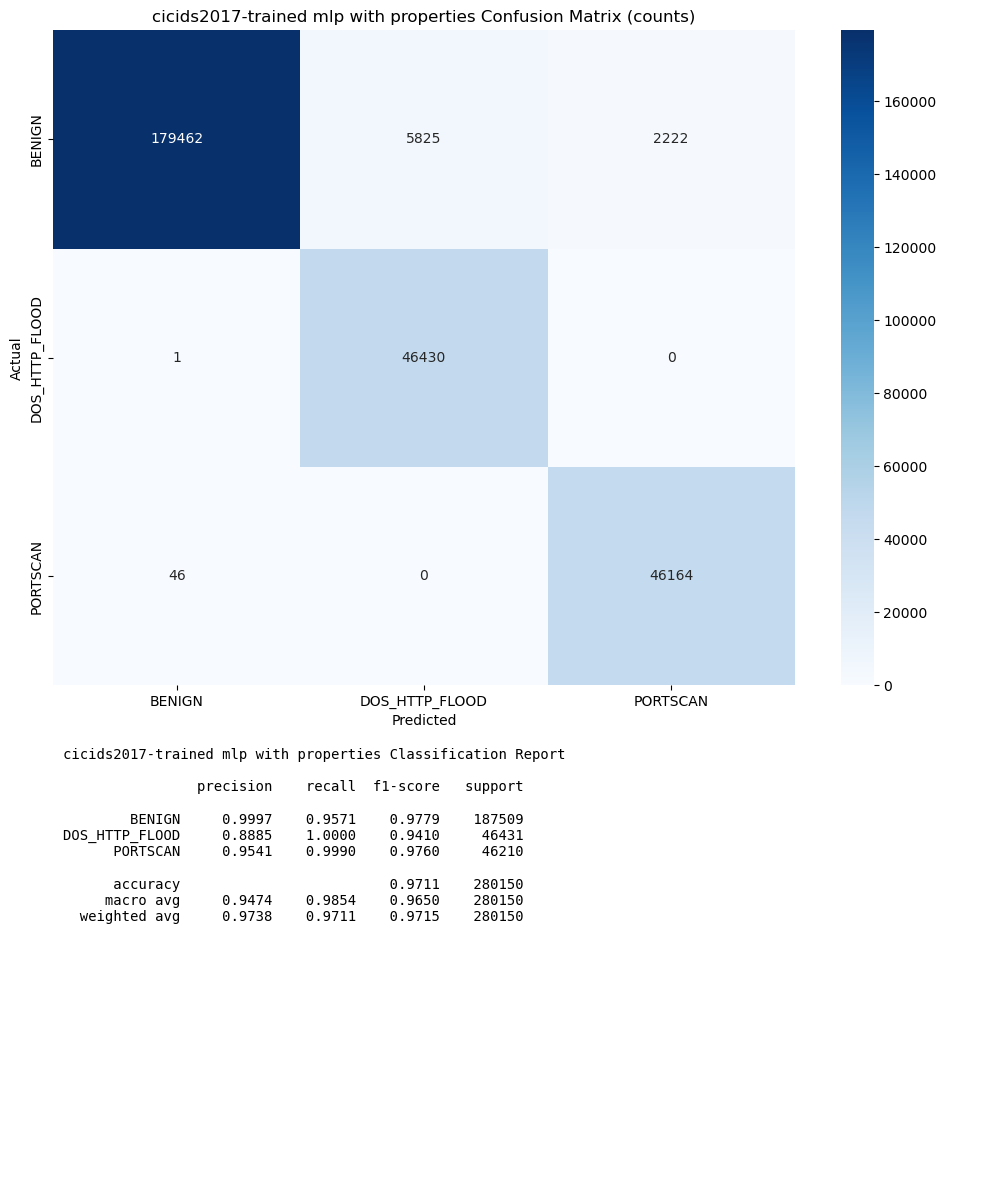


Saved model to: models/mlp_property_cicids2017.joblib


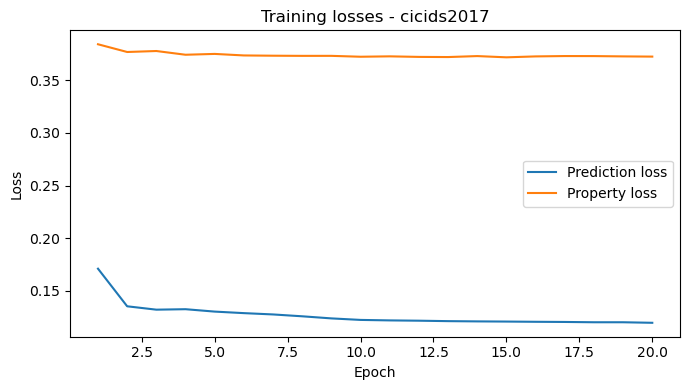


TRAINING ON: CICIOT2023
Shape: (454719, 48)
label
BENIGN            151573
PORTSCAN          151573
DOS_HTTP_FLOOD    151573
Name: count, dtype: int64
Features: 35
['proto', 'service', 'conn_state', 'history', 'duration', 'orig_bytes', 'resp_bytes', 'missed_bytes', 'orig_pkts', 'orig_ip_bytes', 'resp_pkts', 'resp_ip_bytes', 'orig_pkt_rate', 'orig_byte_rate', 'pkt_asymmetry', 'byte_asymmetry', 'time_elapsed', 'flood_rate', 'uniq_dst_ports', 'pkts_per_port', 'scan_duration', 'fail_ratio', 'is_tcp', 'is_http', 'valid_input', 'valid_tcp_handshake', 'valid_duration', 'valid_packet_size', 'valid_iat', 'dos_http_mal_time_elapsed', 'dos_http_mal_flood_rate', 'portscan_many_ports', 'portscan_few_pkts_per_port', 'portscan_short_duration', 'portscan_high_fail_ratio']
Building properties for logic: DL2
Initial property loss:  0.03222856670618057
Initial property sat:  0.5668103694915771
Property stats: {'DOS_HTTP_FLOOD_loss': 0.0, 'DOS_HTTP_FLOOD_sat': 1.0, 'DOS_HTTP_FLOOD_active_frac': 0.0, 'DOS

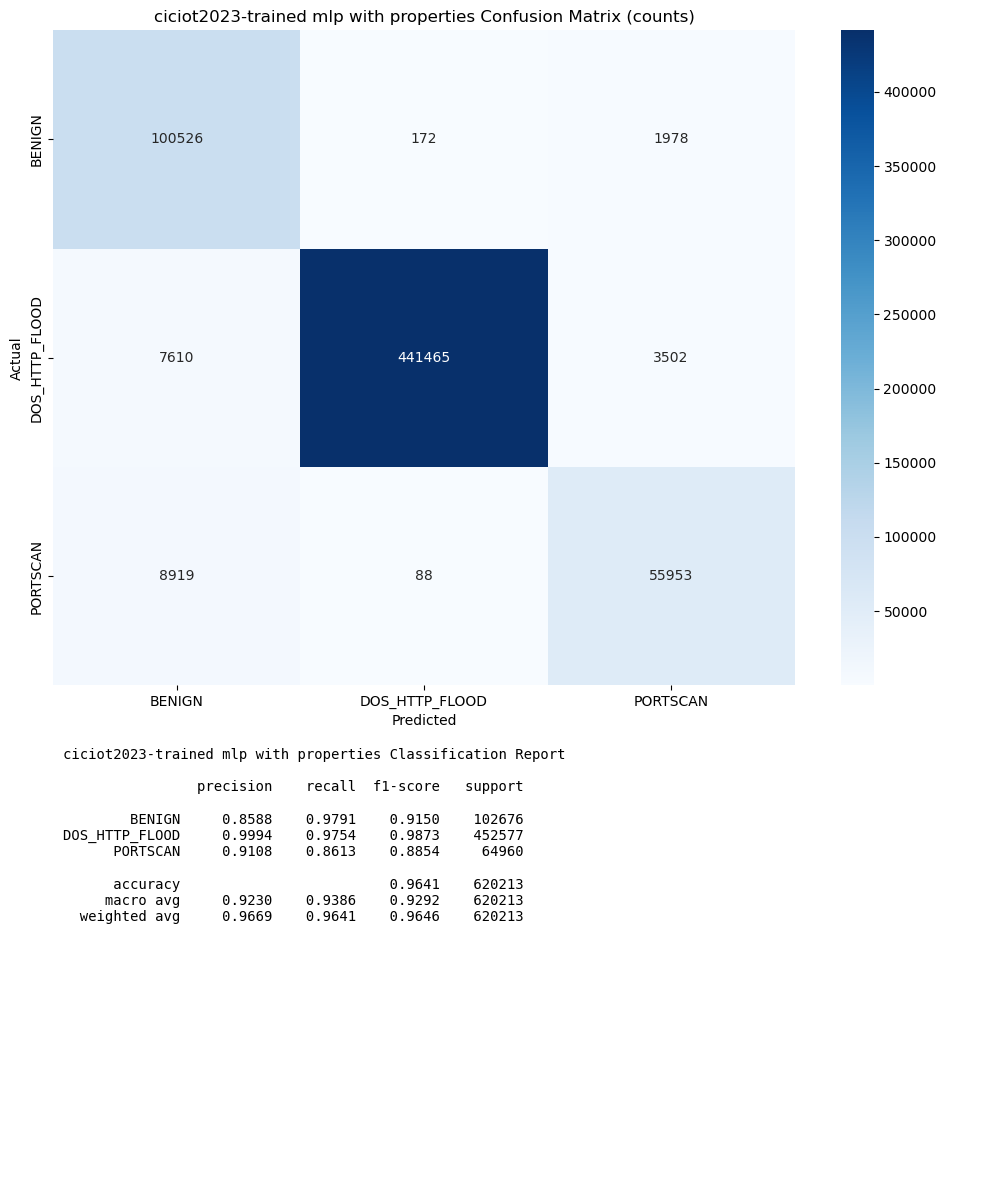


Saved model to: models/mlp_property_ciciot2023.joblib


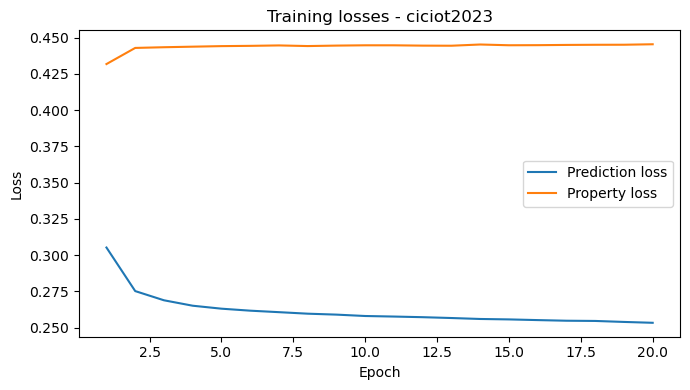


TRAINING ON: CICIDS2017
Shape: (258051, 48)
label
PORTSCAN          86017
DOS_HTTP_FLOOD    86017
BENIGN            86017
Name: count, dtype: int64
Features: 35
['proto', 'service', 'conn_state', 'history', 'duration', 'orig_bytes', 'resp_bytes', 'missed_bytes', 'orig_pkts', 'orig_ip_bytes', 'resp_pkts', 'resp_ip_bytes', 'orig_pkt_rate', 'orig_byte_rate', 'pkt_asymmetry', 'byte_asymmetry', 'time_elapsed', 'flood_rate', 'uniq_dst_ports', 'pkts_per_port', 'scan_duration', 'fail_ratio', 'is_tcp', 'is_http', 'valid_input', 'valid_tcp_handshake', 'valid_duration', 'valid_packet_size', 'valid_iat', 'dos_http_mal_time_elapsed', 'dos_http_mal_flood_rate', 'portscan_many_ports', 'portscan_few_pkts_per_port', 'portscan_short_duration', 'portscan_high_fail_ratio']
Building properties for logic: DL2
Initial property loss:  0.11906056851148605
Initial property sat:  0.5
Property stats: {'DOS_HTTP_FLOOD_loss': 0.2381211370229721, 'DOS_HTTP_FLOOD_sat': 0.0, 'DOS_HTTP_FLOOD_active_frac': 0.078125, 'D

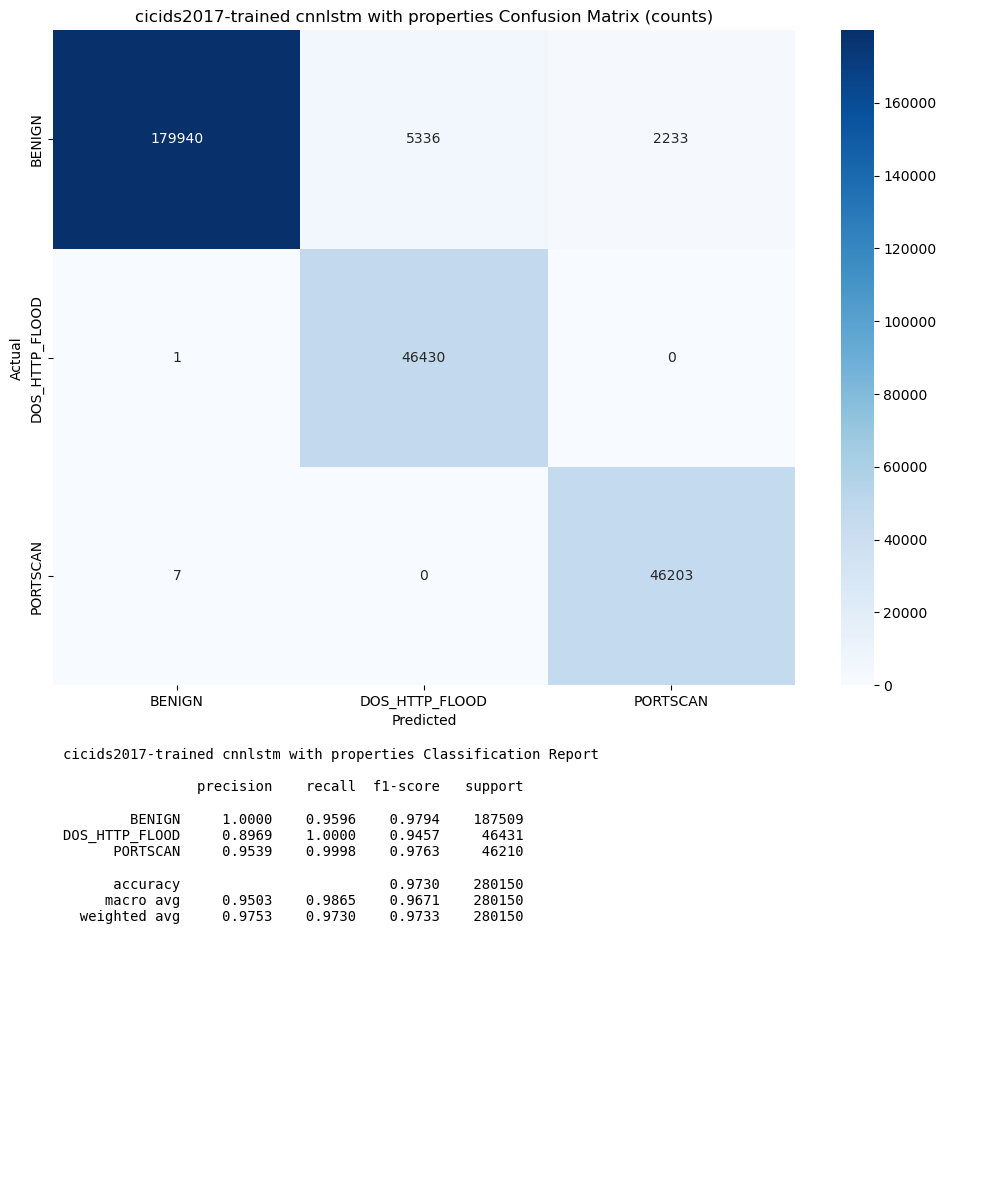


Saved model to: models/cnnlstm_property_cicids2017.joblib


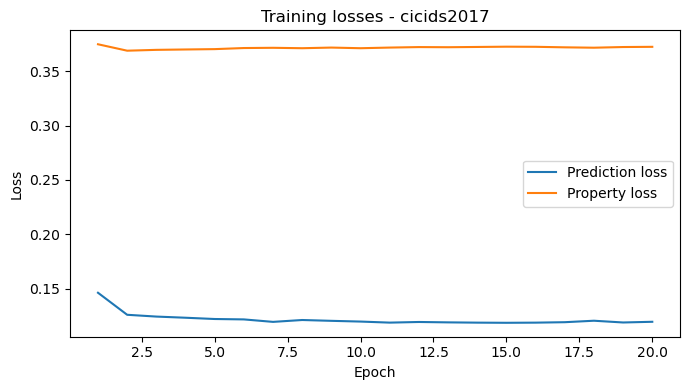


TRAINING ON: CICIOT2023
Shape: (454719, 48)
label
BENIGN            151573
PORTSCAN          151573
DOS_HTTP_FLOOD    151573
Name: count, dtype: int64
Features: 35
['proto', 'service', 'conn_state', 'history', 'duration', 'orig_bytes', 'resp_bytes', 'missed_bytes', 'orig_pkts', 'orig_ip_bytes', 'resp_pkts', 'resp_ip_bytes', 'orig_pkt_rate', 'orig_byte_rate', 'pkt_asymmetry', 'byte_asymmetry', 'time_elapsed', 'flood_rate', 'uniq_dst_ports', 'pkts_per_port', 'scan_duration', 'fail_ratio', 'is_tcp', 'is_http', 'valid_input', 'valid_tcp_handshake', 'valid_duration', 'valid_packet_size', 'valid_iat', 'dos_http_mal_time_elapsed', 'dos_http_mal_flood_rate', 'portscan_many_ports', 'portscan_few_pkts_per_port', 'portscan_short_duration', 'portscan_high_fail_ratio']
Building properties for logic: DL2
Initial property loss:  0.0
Initial property sat:  1.0
Property stats: {'DOS_HTTP_FLOOD_loss': 0.0, 'DOS_HTTP_FLOOD_sat': 1.0, 'DOS_HTTP_FLOOD_active_frac': 0.0, 'DOS_HTTP_FLOOD_valid_input_frac': 

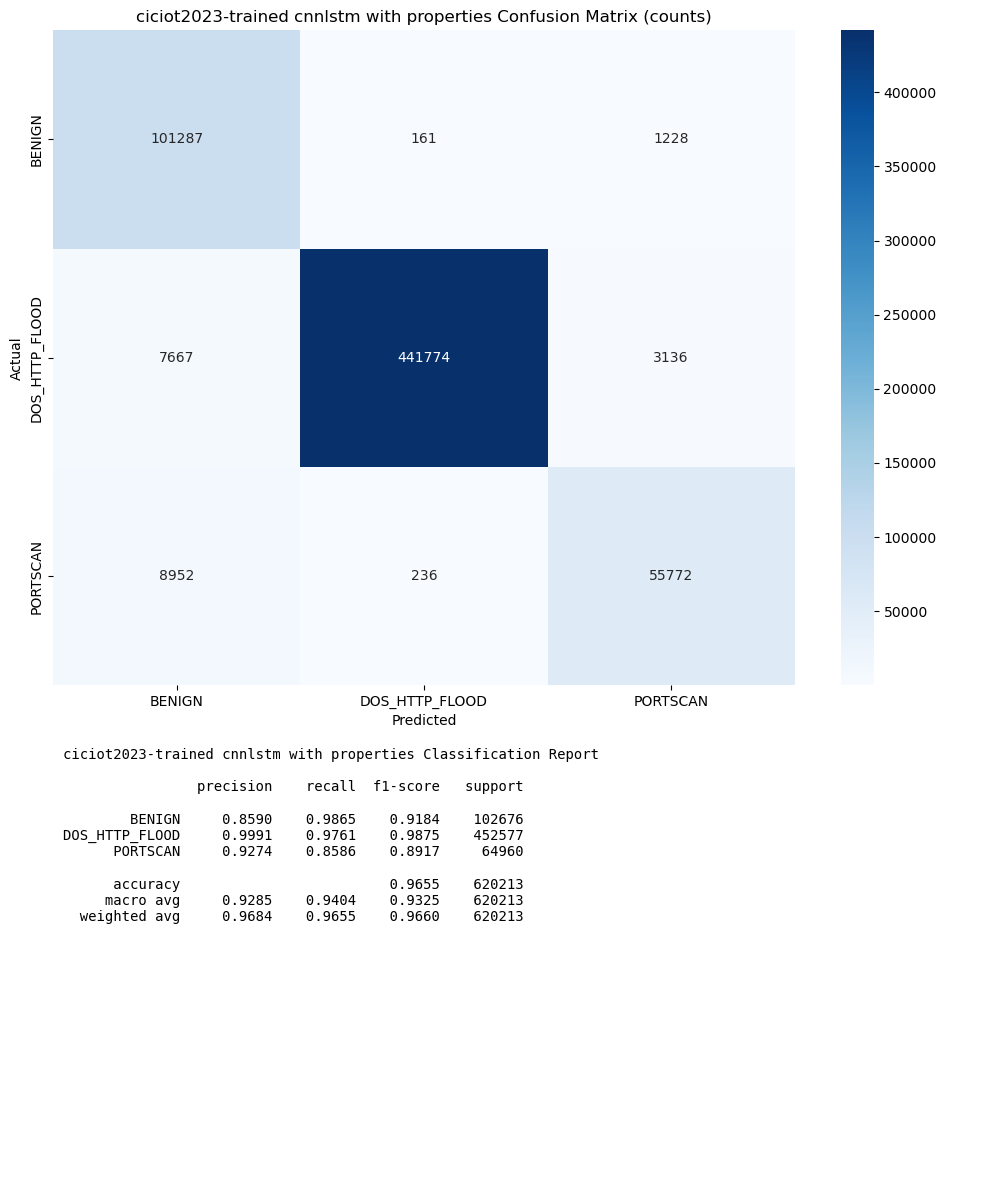


Saved model to: models/cnnlstm_property_ciciot2023.joblib


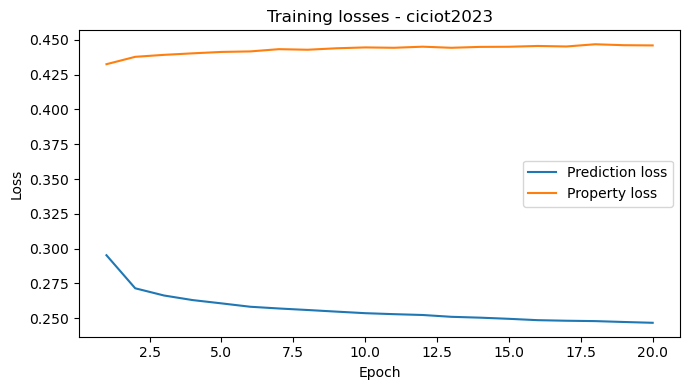

In [7]:
for MODEL_TYPE in MODEL_TYPES:
    for dataset_name, dataset_config in DATASETS.items():
        print("\n" + "=" * 70)
        print(f"TRAINING ON: {dataset_name.upper()}")
        print("=" * 70)

        df_train = dataset_config["data_train"].copy()
        df_test = dataset_config["data_test"].copy()

        X_train = df_train[FEATURES]
        X_test = df_test[FEATURES]
        y_train = df_train["label"]
        y_test = df_test["label"]

        feature_cols = [c for c in FEATURES if c in df_train.columns]

        print("Shape:", df_train.shape)
        print(df_train["label"].value_counts())
        print("Features:", len(feature_cols))
        print(feature_cols)

        label_encoder = LabelEncoder()
        y_train_enc = label_encoder.fit_transform(y_train)
        y_test_enc = label_encoder.transform(y_test)

        X_train_bal = X_train.copy()
        X_test_local = X_test.copy()

        categorical_cols = X_train_bal.select_dtypes(include=["object", "string", "bool"]).columns.tolist()
        ordinal_encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

        if len(categorical_cols) > 0:
            X_train_bal[categorical_cols] = ordinal_encoder.fit_transform(X_train_bal[categorical_cols])
            X_test_local[categorical_cols] = ordinal_encoder.transform(X_test_local[categorical_cols])

        binary_cols = [c for c in PROPERTY_BOOLEAN_FEATURES if c in feature_cols]
        continuous_cols = [c for c in feature_cols if c not in binary_cols]

        X_train_scaled_df = X_train_bal.copy()
        X_test_scaled_df = X_test_local.copy()

        scaler = StandardScaler()

        if len(continuous_cols) > 0:
            X_train_scaled_df[continuous_cols] = scaler.fit_transform(X_train_bal[continuous_cols])
            X_test_scaled_df[continuous_cols] = scaler.transform(X_test_local[continuous_cols])

        X_train_scaled = X_train_scaled_df[feature_cols].values
        X_test_scaled = X_test_scaled_df[feature_cols].values

        # Restore binary columns to original 0/1 values
        for col in binary_cols:
            X_train_scaled_df[col] = X_train_bal[col].values
            X_test_scaled_df[col] = X_test_local[col].values

        # binary_cols are left untouched
        X_train_scaled = X_train_scaled_df[feature_cols].values
        X_test_scaled = X_test_scaled_df[feature_cols].values

        X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32).unsqueeze(1)
        X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).unsqueeze(1)

        y_train_tensor = torch.tensor(y_train_enc, dtype=torch.long)
        y_test_tensor = torch.tensor(y_test_enc, dtype=torch.long)

        train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
        test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

        train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
        test_loader = DataLoader(test_dataset, batch_size=1024, shuffle=False)

        num_classes = len(label_encoder.classes_)
        model = build_model(
            model_type=MODEL_TYPE,
            n_features=len(feature_cols),
            num_classes=num_classes,
        ).to(device)

        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

        properties = build_properties(
            device=device,
            scaler=scaler,
            feature_names=feature_cols,
            label_encoder=label_encoder,
            logic=pml_logics.DL2()
        )

        x_batch, _ = next(iter(train_loader))
        x_batch = x_batch.to(device)
        total_loss, total_sat, prop_stats = properties.compute_loss(model, x_batch)

        print("Initial property loss: ", total_loss.item())
        print("Initial property sat: ", total_sat.item())
        print("Property stats:", prop_stats)

        history = []

        for epoch in range(NUM_EPOCHS):
            model.train()

            pred_losses = []
            prop_losses = []
            last_stats = {}

            for x_batch, y_batch in train_loader:
                x_batch = x_batch.to(device)
                y_batch = y_batch.to(device)

                optimizer.zero_grad()

                logits = model(x_batch)
                pred_loss = criterion(logits, y_batch)

                total_loss, total_sat, prop_stats = properties.compute_loss(model, x_batch)
                
                # For the first few epochs, focus on prediction loss to allow the model to learn basic patterns. 
                # After that, start incorporating the property loss to guide the model towards satisfying the properties.
                # if epoch < 3:
                #     loss = pred_loss
                # else:
                loss = pred_loss + LAMBDA_PROP * total_loss
                loss.backward()
                optimizer.step()

                pred_losses.append(pred_loss.item())
                prop_losses.append(total_loss.item())
                last_stats = prop_stats

            avg_pred_loss = float(np.mean(pred_losses))
            avg_prop_loss = float(np.mean(prop_losses))

            history.append({
                "epoch": epoch + 1,
                "pred_loss": avg_pred_loss,
                "prop_loss": avg_prop_loss,
                **last_stats,
            })

            print(
                f"Epoch {epoch+1:02d} | "
                f"pred_loss={avg_pred_loss:.4f} | "
                f"prop_loss={avg_prop_loss:.4f} | "
                f"{', '.join(f'{k}={v:.4f}' for k, v in last_stats.items())}"
            )

        # evaluation
        model.eval()
        all_preds = []
        all_true = []

        with torch.no_grad():
            for x_batch, y_batch in test_loader:
                x_batch = x_batch.to(device)

                logits = model(x_batch)
                preds = torch.argmax(logits, dim=1).cpu().numpy()

                all_preds.extend(preds)
                all_true.extend(y_batch.cpu().numpy())

        y_true_labels = label_encoder.inverse_transform(np.array(all_true))
        y_pred_labels = label_encoder.inverse_transform(np.array(all_preds))

        evaluate_model(
            y_true_labels,
            y_pred_labels,
            model_name=f"{dataset_name}-trained {MODEL_TYPE} with properties",
            path_to_save=f"{date.today()}/train_with_properties_evaluation_results"
        )

        os.makedirs("models", exist_ok=True)
        save_path = f"models/{MODEL_TYPE}_property_{dataset_name}.joblib"

        joblib.dump(
            {
                "model": model.cpu(),
                "ordinal_encoder": ordinal_encoder,
                "scaler": scaler,
                "label_encoder": label_encoder,
                "features": feature_cols,
                "categorical_cols": list(categorical_cols),
            },
            save_path,
        )

        print(f"\nSaved model to: {save_path}")

        history_df = pd.DataFrame(history)
        plt.figure(figsize=(7, 4))
        plt.plot(history_df["epoch"], history_df["pred_loss"], label="Prediction loss")
        plt.plot(history_df["epoch"], history_df["prop_loss"], label="Property loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title(f"Training losses - {dataset_name}")
        plt.legend()
        plt.tight_layout()
        plt.show()

In [8]:
df_ciciot2023_train

,ts,uid,id.orig_h,id.orig_p,id.resp_h,id.resp_p,proto,service,duration,orig_bytes,...,valid_duration,valid_packet_size,valid_iat,dos_http_mal_time_elapsed,dos_http_mal_flood_rate,portscan_many_ports,portscan_few_pkts_per_port,portscan_short_duration,portscan_high_fail_ratio,label
0,1.665174e+09,CnRQfINxmpoI74oc7,192.168.137.133,25338,3.221.182.58,32100,udp,-,0.120246,4.0,...,1,0,1,0,0,0,1,1,0,BENIGN
1,1.665232e+09,C8iISiR7wJJTMcWak,192.168.137.39,56907,8.8.8.8,53,udp,dns,0.045778,35.0,...,1,0,1,0,1,0,0,1,0,BENIGN
2,1.664211e+09,C5ceh82cc4M9iOnIq7,192.168.137.178,42707,192.168.137.234,5001,tcp,-,0.000000,0.0,...,1,0,0,1,0,1,1,1,1,PORTSCAN
3,1.664806e+09,Cu0JZN1rNoTL71BLUe,192.168.137.51,61431,192.168.137.1,53,udp,dns,0.079916,38.0,...,1,0,1,0,0,0,0,0,0,ATTACK
4,1.659987e+09,C4mpnd1zxuzChq3cM2,192.168.137.66,58604,192.168.137.211,8080,tcp,-,0.043997,0.0,...,1,0,1,1,0,0,0,0,1,DOS_HTTP_FLOOD
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
606287,1.660676e+09,CKb3T32cMU1VS0qAr4,192.168.137.156,14081,192.168.137.99,55442,tcp,-,394.761645,904504261.0,...,0,1,1,1,1,0,0,0,0,ATTACK
606288,1.665203e+09,CeZGxA13RwFnqHaPzd,192.168.137.133,12781,47.112.162.49,32100,udp,-,0.175959,4.0,...,1,0,1,0,0,0,1,1,0,BENIGN
606289,1.659984e+09,CuOl403AQuRUy3wmrj,192.168.137.66,49834,192.168.137.235,80,tcp,-,0.000000,0.0,...,1,0,0,1,0,0,0,0,1,DOS_HTTP_FLOOD
606290,1.660668e+09,CDJjEmCQZhTsABg8c,192.168.137.15,60209,192.168.137.123,4070,tcp,-,678.055844,491844882.0,...,0,1,1,1,1,0,0,0,0,ATTACK


# Cross-data Eval

In [9]:
from utils.evaluation import (
    load_and_evaluate_model
)

In [10]:
df_cicids2017 = pd.read_csv("cicids2017_preprocessed_with_properties.tsv", on_bad_lines="skip", delimiter="\t")
df_ciciot2023 = pd.read_csv("ciciot2023_preprocessed_with_properties.tsv", on_bad_lines="skip", delimiter="\t")

C:\Users\Rasmus\AppData\Local\Temp\ipykernel_22348\2439053677.py:2: DtypeWarning: Columns (0: id.orig_p, 1: scan_duration) have mixed types. Specify dtype option on import or set low_memory=False.
  df_ciciot2023 = pd.read_csv("ciciot2023_preprocessed_with_properties.tsv", on_bad_lines="skip", delimiter="\t")


In [11]:
df_cicids2017_filtered = filter_labels(df_cicids2017, TARGET_LABELS)
df_ciciot2023_filtered = filter_labels(df_ciciot2023, TARGET_LABELS)

In [12]:
DATASETS_EVAL = {
    "cicids2017": {"X": df_cicids2017_filtered[FEATURES], "y": df_cicids2017_filtered["label"]},
    "ciciot2023": {"X": df_ciciot2023_filtered[FEATURES], "y": df_ciciot2023_filtered["label"]},
}
MODEL_TYPES_EVAL = [ 
    "mlp", 
    "cnnlstm"
]


EVALUATING CICIDS2017-MLP ON CICIOT2023

=== CICIDS2017-MLP TESTED ON CICIOT2023 Classification Report ===

                precision    recall  f1-score   support

        BENIGN     0.1785    0.9284    0.2995    342255
DOS_HTTP_FLOOD     0.9842    0.0235    0.0458   1508589
      PORTSCAN     0.6613    0.7686    0.7109    216533

      accuracy                         0.2513   2067377
     macro avg     0.6080    0.5735    0.3521   2067377
  weighted avg     0.8170    0.2513    0.1575   2067377

Overall Accuracy: 0.2513

=== Per-Label Accuracy ===

BENIGN: 0.9284
DOS_HTTP_FLOOD: 0.0235
PORTSCAN: 0.7686


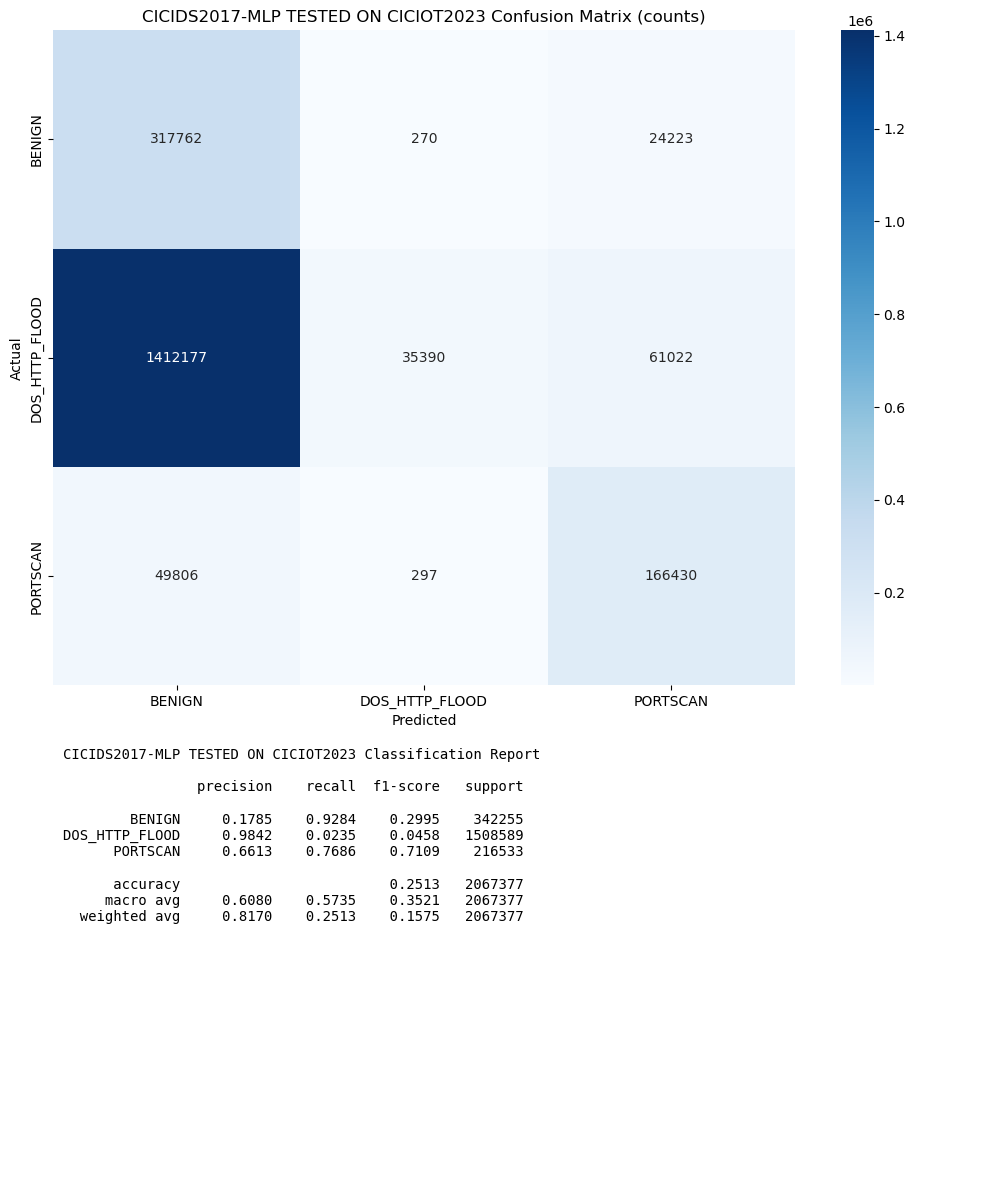


EVALUATING CICIOT2023-MLP ON CICIDS2017

=== CICIOT2023-MLP TESTED ON CICIDS2017 Classification Report ===

                precision    recall  f1-score   support

        BENIGN     0.9996    0.7332    0.8459    625030
DOS_HTTP_FLOOD     0.7280    0.9001    0.8050    154769
      PORTSCAN     0.5415    0.9985    0.7022    154034

      accuracy                         0.8046    933833
     macro avg     0.7564    0.8772    0.7843    933833
  weighted avg     0.8790    0.8046    0.8154    933833

Overall Accuracy: 0.8046

=== Per-Label Accuracy ===

BENIGN: 0.7332
DOS_HTTP_FLOOD: 0.9001
PORTSCAN: 0.9985


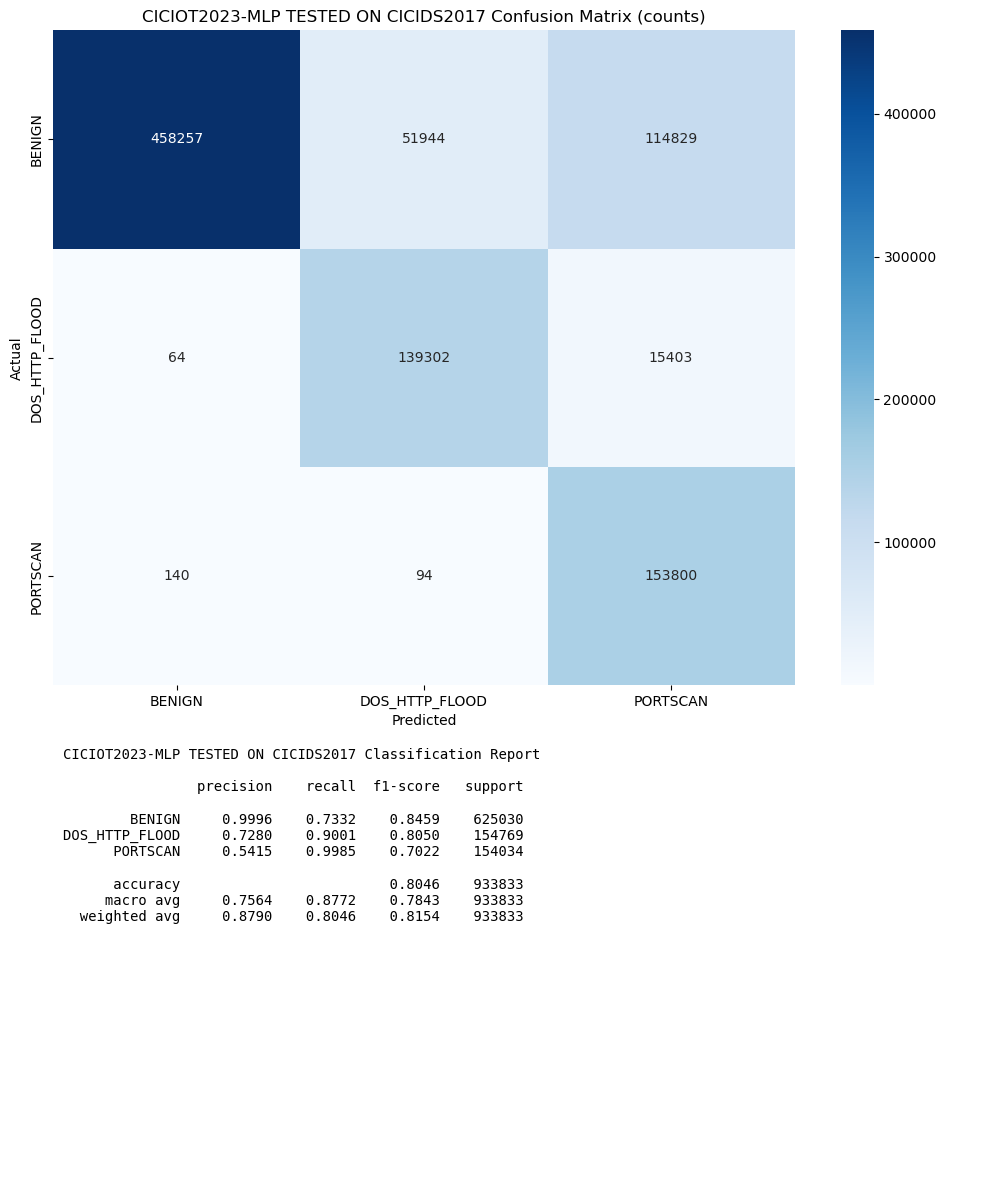


EVALUATING CICIDS2017-CNNLSTM ON CICIOT2023

=== CICIDS2017-CNNLSTM TESTED ON CICIOT2023 Classification Report ===

                precision    recall  f1-score   support

        BENIGN     0.1948    0.9738    0.3246    342255
DOS_HTTP_FLOOD     0.9986    0.1188    0.2124   1508589
      PORTSCAN     0.9397    0.7661    0.8441    216533

      accuracy                         0.3282   2067377
     macro avg     0.7110    0.6196    0.4603   2067377
  weighted avg     0.8594    0.3282    0.2971   2067377

Overall Accuracy: 0.3282

=== Per-Label Accuracy ===

BENIGN: 0.9738
DOS_HTTP_FLOOD: 0.1188
PORTSCAN: 0.7661


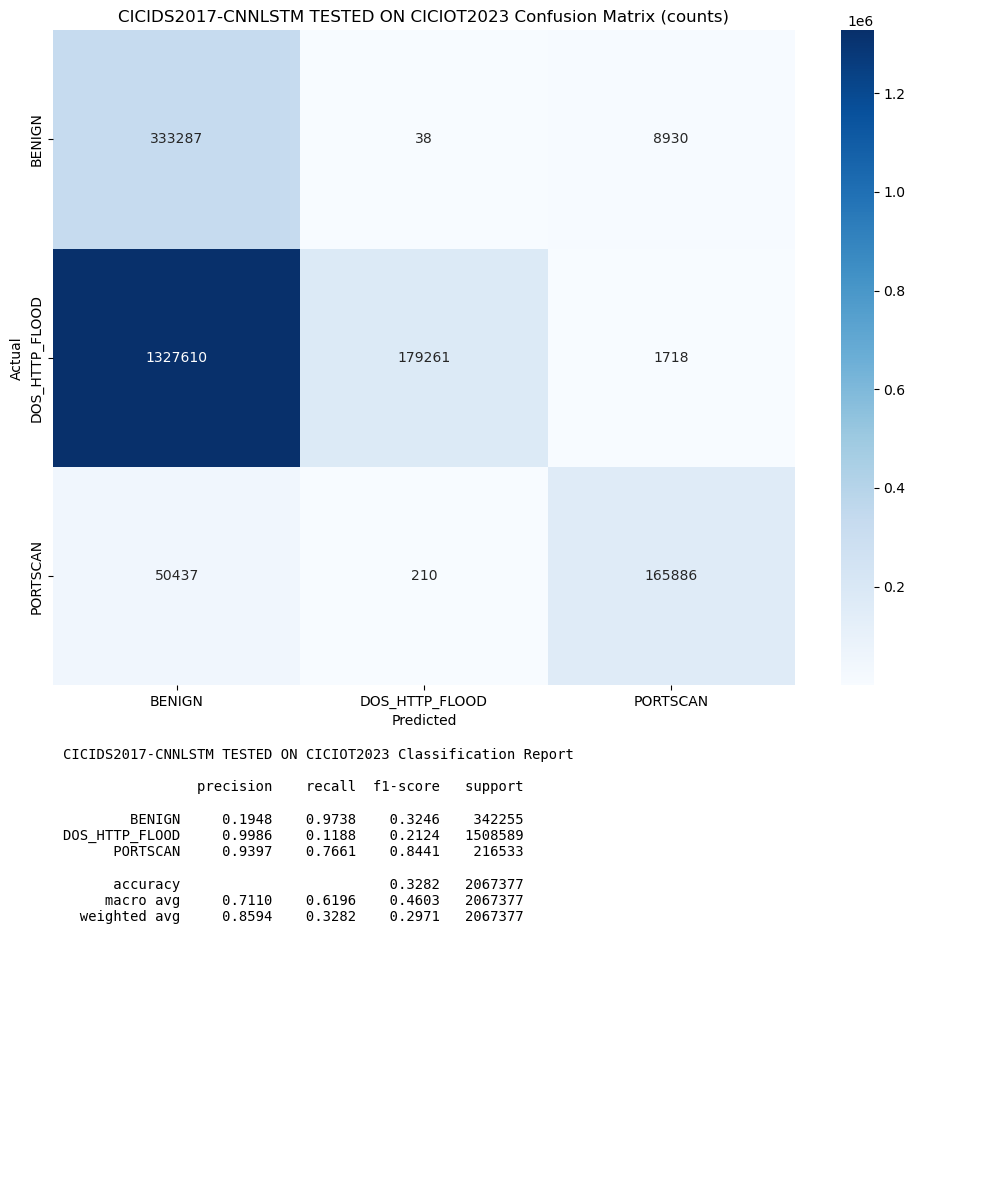


EVALUATING CICIOT2023-CNNLSTM ON CICIDS2017

=== CICIOT2023-CNNLSTM TESTED ON CICIDS2017 Classification Report ===

                precision    recall  f1-score   support

        BENIGN     0.9920    0.5608    0.7165    625030
DOS_HTTP_FLOOD     0.6347    0.9823    0.7712    154769
      PORTSCAN     0.4509    0.9982    0.6212    154034

      accuracy                         0.7028    933833
     macro avg     0.6926    0.8471    0.7030    933833
  weighted avg     0.8435    0.7028    0.7099    933833

Overall Accuracy: 0.7028

=== Per-Label Accuracy ===

BENIGN: 0.5608
DOS_HTTP_FLOOD: 0.9823
PORTSCAN: 0.9982


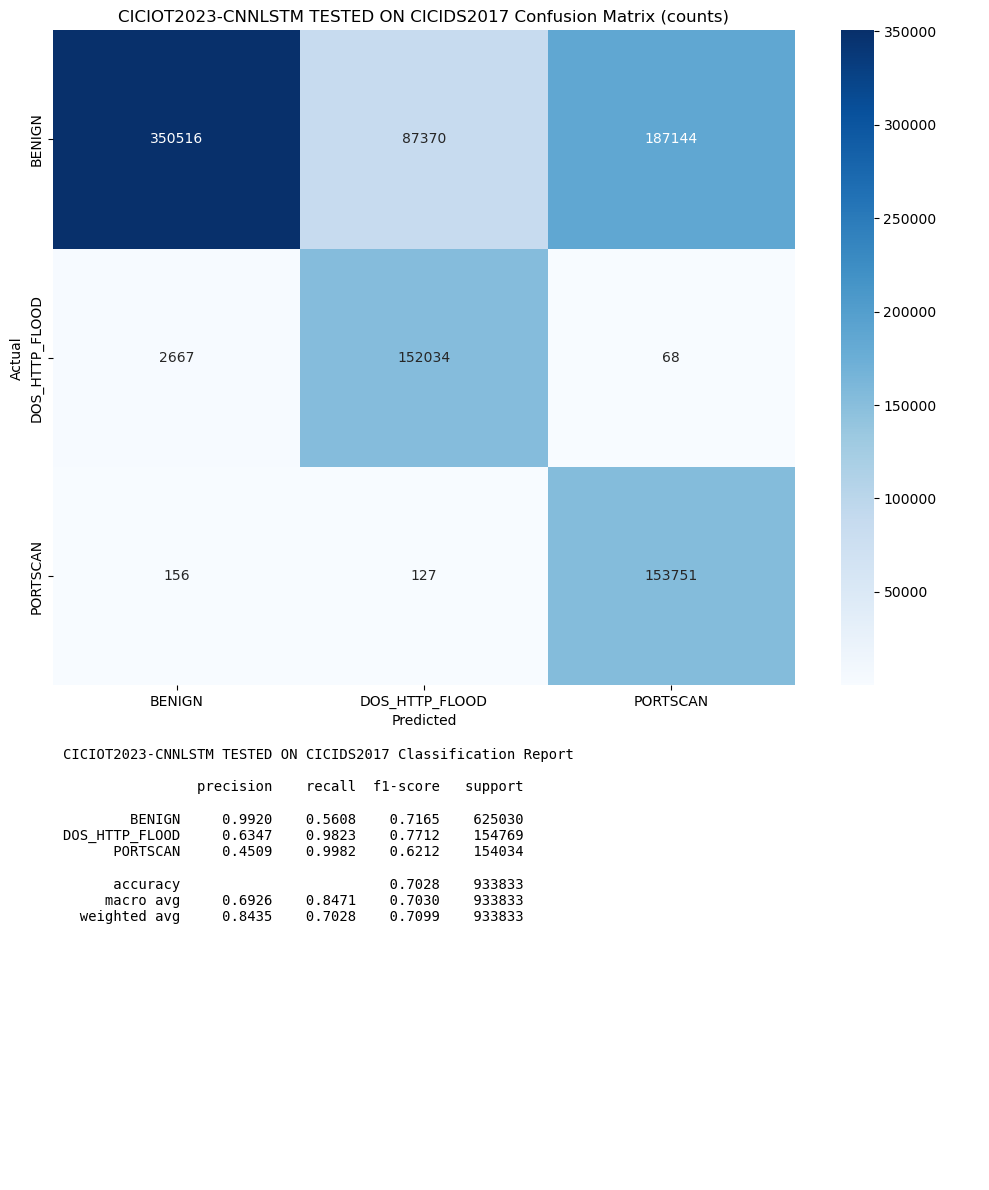

In [13]:
for MODEL_TYPE in MODEL_TYPES_EVAL:
    for dataset_name, dataset_config in DATASETS_EVAL.items():
        if dataset_name == "cicids2017":
            X_test = DATASETS_EVAL["ciciot2023"]["X"]
            y_test = DATASETS_EVAL["ciciot2023"]["y"]
            test_name = "CICIOT2023"
        else:
            X_test = DATASETS_EVAL["cicids2017"]["X"]
            y_test = DATASETS_EVAL["cicids2017"]["y"]
            test_name = "CICIDS2017"
        print("\n" + "=" * 70)
        print(f"EVALUATING {dataset_name.upper()}-{MODEL_TYPE.upper()} ON {test_name}")
        print("=" * 70)
        joblib_path = f"models/{MODEL_TYPE}_property_{dataset_name}.joblib"
        load_and_evaluate_model(
            joblib_path=joblib_path,
            X=X_test,
            y_true=y_test,
            model_name=f"{dataset_name.upper()}-{MODEL_TYPE.upper()} TESTED ON {test_name}",
            batch_size=1024,
            path_to_save=f"{date.today()}/cross_dataset_evaluation_results",
        )